In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("C:\\ProyectoML\\Datasets\\25001.txt", encoding='ISO-8859-1', sep ="\s+",na_values="Nulo",skiprows= 18)


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\tocha\AppData\Local\Temp\ipykernel_4448\3866571238.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("C:\\ProyectoML\\Datasets\\25001.txt", encoding='ISO-8859-1', sep ="\s+",na_values="Nulo",skiprows= 18)


FASE 1- CONOCER NUESTROS DATOS

In [4]:
df.head()

,FECHA,(MM),(MM).1,(°C),(°C).1
0,01/01/1961,0.0,NaN,25.0,13.0
1,02/01/1961,0.0,NaN,27.5,14.0
2,03/01/1961,0.0,NaN,31.0,11.0
3,04/01/1961,0.0,NaN,32.0,13.0
4,05/01/1961,0.0,NaN,29.0,14.0


In [5]:
df.shape

(19575, 5)

In [9]:
df.dtypes

FECHA         str
PRECIP    float64
EVAP      float64
TMAX      float64
TMIN      float64
dtype: object

In [13]:
#Como se analizo en gracias al metodo de dtypes, FECHA queda como str, sin embargo no nos sirve para hacer analisis dentro de la variable
#para ello lo convertimos en un datetime.
df['FECHA'] = pd.to_datetime(df['FECHA'], dayfirst= True)
df.dtypes

FECHA     datetime64[us]
PRECIP           float64
EVAP             float64
TMAX             float64
TMIN             float64
dtype: object

In [11]:
#Durante esta parte, eliminamos la celda 19574 ya que no proporciona ningun uso (es una serie de lineas divisoras del cuadro ---------)
df.tail()
df = df.drop(19574)

In [7]:
#En esta parte cambiamos el nombre de las columnas para tener congruencia en la limpieza de los datos y saber que se esta quitando, ademas de 
#ordenar el dataframe base a la fecha.
df.rename(mapper={"(MM)":"PRECIP","(MM).1": "EVAP", "(°C)": "TMAX", "(°C).1": "TMIN"},axis=1, inplace = True) 


In [14]:
#Aqui nos podemos dar cuenta que en la columna de evaporacion hay muchos datos nulos,
#siendo el que mas tiene de todos las columnas, los que menos tienen son los de temperatura maxima y minima.
df.isnull().sum()

FECHA       0
PRECIP     40
EVAP      272
TMAX        5
TMIN        6
dtype: int64

In [15]:
df[df["TMAX"].isnull()]["FECHA"]

2922    1969-01-01
3345    1970-02-28
11284   1992-05-26
12866   1999-04-17
14245   2003-01-31
Name: FECHA, dtype: datetime64[us]

In [16]:
df[df["TMIN"].isnull()]["FECHA"]

2958    1969-02-06
3345    1970-02-28
11286   1992-06-17
12867   1999-04-24
14245   2003-01-31
17485   2012-05-09
Name: FECHA, dtype: datetime64[us]

In [24]:
#Con esto nos decidimos por TMAX para hacer el analisis de los datos, ya que es la variable que menos datos tiene
#Para ubicar los nulos que tiene cada decada dentro de TMAX hicimos lo siguiente
df["decada"] = (df["FECHA"].dt.year // 10) * 10
df[df["TMAX"].isnull()].groupby("decada").size()

decada
1960    1
1970    1
1990    2
2000    1
dtype: int64

In [48]:
df[df["decada"] == 1980]["TMAX"].describe()

count    3592.000000
mean       34.645741
std         3.686472
min        18.000000
25%        32.500000
50%        35.000000
75%        37.000000
max        43.000000
Name: TMAX, dtype: float64

In [49]:
df[df["decada"] == 2010]["TMAX"].describe()

count    2864.000000
mean       33.637744
std         3.100506
min        20.000000
25%        32.000000
50%        34.000000
75%        36.000000
max        41.000000
Name: TMAX, dtype: float64

In [50]:
#Conociendo las decadas que tienen datos nulos, optamos con trabajar con la decada de los 00s, ya que es la que tiene
#menos desviacion estandar, sinonimo de poder imputar los datos con mayor facilidad.
#Con esto descubierto, vamos a hacer un nuevo dataframe con solo los datos de esa decada para hacer el analisis de los datos nulos y su imputacion.
df_decada = df[df["decada"] == 2010].copy()
df_decada.shape

(2864, 6)

FASE 2 - PREPARACION DE DATOS

In [51]:
#un caso como este, los datos se trabajan mejor con valores entre 0 y 1, por lo que se opta por normalizar los datos de TMAX para 
#poder imputar los datos nulos con mayor facilidad.

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
tmax_values = df_decada["TMAX"].values.reshape(-1, 1)
tmax_scaled = scaler.fit_transform(tmax_values)

In [52]:
#creamos una secuencia de alrededor de 30 pares de entrenamiento donde 30 dias predicen el dia siguiente 

def crear_secuencias(data, pasos=30):
    X, y = [], []
    for i in range(len(data) - pasos):
        X.append(data[i:i+pasos])
        y.append(data[i+pasos])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tmax_scaled)
print(X.shape, y.shape)

(2834, 30, 1) (2834, 1)


In [53]:
#Aqui hacemos la division de 70/30 que nos pidieron a la hora de entrenar el modelo, con esto separamos los datos de entrenamiento y prueba para poder evaluar el modelo posteriormente.
split = int(len(X) * 0.7)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")

Entrenamiento: (1983, 30, 1)
Prueba: (851, 30, 1)


FASE 3 - CONSTRUIR EL MODELO

In [54]:
#La arquitectura recomendada para una serie de tiempo hidrometeorologica es una LSTM, por lo que se opta por esta arquitectura para el modelo de prediccion de temperatura maxima.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(30, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

c:\ProyectoML\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,345 (114.63 KB)

 Trainable params: 29,345 (114.63 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
#Con LSTM buscamos recordar patrones de dias anteriores, exactamente lo que necesitamos en esta ocasion para predecir la temperatura
# Dandonos el resumen del modelo pasamos a la fase de entrenamiento donde le daremos las secuencias que debera de entrenar

FASE 4 - ENTRENAR EL MODELO

In [55]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.0435 - mae: 0.1532 - val_loss: 0.0082 - val_mae: 0.0688
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0185 - mae: 0.1053 - val_loss: 0.0086 - val_mae: 0.0727
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0184 - mae: 0.1054 - val_loss: 0.0085 - val_mae: 0.0723
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0169 - mae: 0.0997 - val_loss: 0.0094 - val_mae: 0.0780
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0169 - mae: 0.1001 - val_loss: 0.0082 - val_mae: 0.0705
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0169 - mae: 0.0996 - val_loss: 0.0081 - val_mae: 0.0702
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0166 - mae: 0.0994 - val_loss: 0.0093 - val_mae: 0.0705
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0166 - mae: 0.0984 - val_loss: 0.0086 - val_mae: 0.0733
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.016

In [ ]:
#En la ultima secuencia notamos que el modelo tomo un buen rumbo, el val loss esta por debajo de loss, lo que indica que 
#el modelo no esta sobreajustado y generaliza bien los datos

#Para continuar con la siguiente fase, necesitaremos evaluar el modelo utilzando las metricas para modelos de regresion, los cuales seran tanto
#el MSE y el R2, incluyendo tambien al MAE para tener una mejor idea de la precision del modelo.


FASE 5 - EVALUAR AL MODELO

In [56]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Hacer predicciones
y_pred = model.predict(X_test)

# Desnormalizar los valores
y_test_real = scaler.inverse_transform(y_test)
y_pred_real = scaler.inverse_transform(y_pred)

# Calcular métricas
mse = mean_squared_error(y_test_real, y_pred_real)
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²:  {r2:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
MSE: 4.2396
MAE: 1.4786
R²:  0.5007


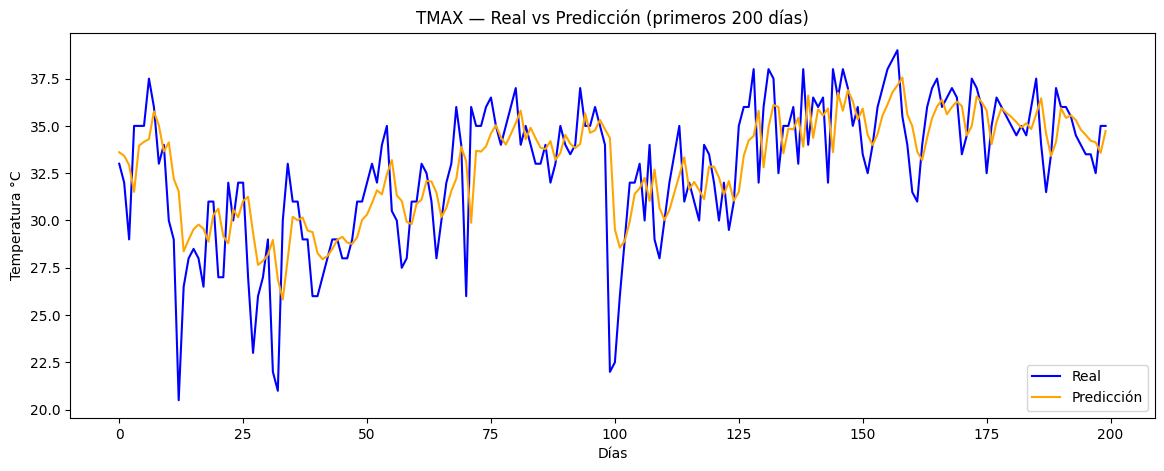

In [57]:
#Los resultados arrojaron que el modelo puede ser mejorable, Para imputación de datos climáticos idealmente quieres un R² por encima de 0.75.
#Para darnos una idea, buscamos visualizar el modelo y que tan bien predice comparando las predicciones con los valores reales.
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(y_test_real[:200], label="Real", color="blue")
plt.plot(y_pred_real[:200], label="Predicción", color="orange")
plt.title("TMAX — Real vs Predicción (primeros 200 días)")
plt.xlabel("Días")
plt.ylabel("Temperatura °C")
plt.legend()
plt.show()

In [58]:
#El modelo muestra una tendencia general pero no es muy preciso, para solucionarlo, ampliaremos las secuencias a un rango de 60
# para que asi pueda aprender patrones a mas largo plazo
def crear_secuencias(data, pasos=60):
    X, y = [], []
    for i in range(len(data) - pasos):
        X.append(data[i:i+pasos])
        y.append(data[i+pasos])
    return np.array(X), np.array(y)

X, y = crear_secuencias(tmax_scaled)

split = int(len(X) * 0.7)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model2 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(60, 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model2.compile(optimizer='adam', loss='mse', metrics=['mae'])

history2 = model2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)



c:\ProyectoML\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 12s 85ms/step - loss: 0.0348 - mae: 0.1382 - val_loss: 0.0089 - val_mae: 0.0752
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0167 - mae: 0.0990 - val_loss: 0.0092 - val_mae: 0.0767
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 0.0160 - mae: 0.0971 - val_loss: 0.0091 - val_mae: 0.0763
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0160 - mae: 0.0961 - val_loss: 0.0091 - val_mae: 0.0763
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0153 - mae: 0.0949 - val_loss: 0.0081 - val_mae: 0.0691
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 126ms/step - loss: 0.0156 - mae: 0.0953 - val_loss: 0.0080 - val_mae: 0.0685
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 157ms/step - loss: 0.0153 - mae: 0.0946 - val_loss: 0.0080 - val_mae: 0.0691
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - loss: 0.0150 - mae: 0.0936 - val_loss: 0.0080 - val_mae: 0.0675
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 156ms/step

In [59]:
y_pred2 = model2.predict(X_test)

y_test_real2 = scaler.inverse_transform(y_test)
y_pred_real2 = scaler.inverse_transform(y_pred2)

mse2 = mean_squared_error(y_test_real2, y_pred_real2)
mae2 = mean_absolute_error(y_test_real2, y_pred_real2)
r2_2 = r2_score(y_test_real2, y_pred_real2)

print(f"MSE: {mse2:.4f}")
print(f"MAE: {mae2:.4f}")
print(f"R²:  {r2_2:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
MSE: 4.2212
MAE: 1.5044
R²:  0.5047


In [ ]:
#Para sorpresa, el modelo mejoro llegando R2 casi a 0.51, lo que para una decada con pocos datos es un resultado decente.
#Para terminar con este proyecto, sigue la imputacion de datos de 2 anios

FASE FINAL - IMPUTAR LOS DATOS

In [ ]:
# Seleccionamos 2 años completos como lo solicito el profesor (2015 y 2016)
mask_2años = (df_decada["FECHA"].dt.year >= 2015) & (df_decada["FECHA"].dt.year <= 2016)
df_validacion = df_decada[mask_2años].copy()

tmax_real = df_validacion["TMAX"].values.copy()

print(f"Registros a imputar: {len(df_validacion)}")
print(df_validacion["TMAX"].describe())



Registros a imputar: 669
count    669.000000
mean      33.455904
std        3.217525
min       20.500000
25%       32.000000
50%       34.000000
75%       35.500000
max       40.000000
Name: TMAX, dtype: float64


In [62]:
df_decada.loc[mask_2años, "TMAX"] = np.nan
print(f"Nulos generados: {df_decada['TMAX'].isnull().sum()}")

Nulos generados: 669


In [67]:
predicciones_puntual = []

tmax_todos = df_decada["TMAX"].copy()
tmax_todos.loc[mask_2años] = np.nan

for idx in df_decada[mask_2años].index:
    # Tomar 60 días anteriores reales
    pos = df_decada.index.get_loc(idx)
    if pos < 60:
        continue
    
    ventana = df_decada["TMAX"].iloc[pos-60:pos].values
    
    # Si la ventana tiene nulos, rellenar con media
    ventana = pd.Series(ventana).fillna(df_decada["TMAX"].mean()).values
    
    ventana_scaled = scaler.transform(ventana.reshape(-1, 1))
    ventana_input = ventana_scaled.reshape(1, 60, 1)
    
    pred_scaled = model2.predict(ventana_input, verbose=0)
    pred_real = scaler.inverse_transform(pred_scaled)[0, 0]
    predicciones_puntual.append(pred_real)

predicciones_puntual = np.array(predicciones_puntual)
print(f"Predicciones generadas: {len(predicciones_puntual)}")

Predicciones generadas: 669


In [68]:
min_len = min(len(tmax_real), len(predicciones_puntual))

mse_imp = mean_squared_error(tmax_real[:min_len], predicciones_puntual[:min_len])
mae_imp = mean_absolute_error(tmax_real[:min_len], predicciones_puntual[:min_len])
r2_imp = r2_score(tmax_real[:min_len], predicciones_puntual[:min_len])

print(f"MSE: {mse_imp:.4f}")
print(f"MAE: {mae_imp:.4f}")
print(f"R²:  {r2_imp:.4f}")

MSE: 10.1614
MAE: 2.3954
R²:  0.0170


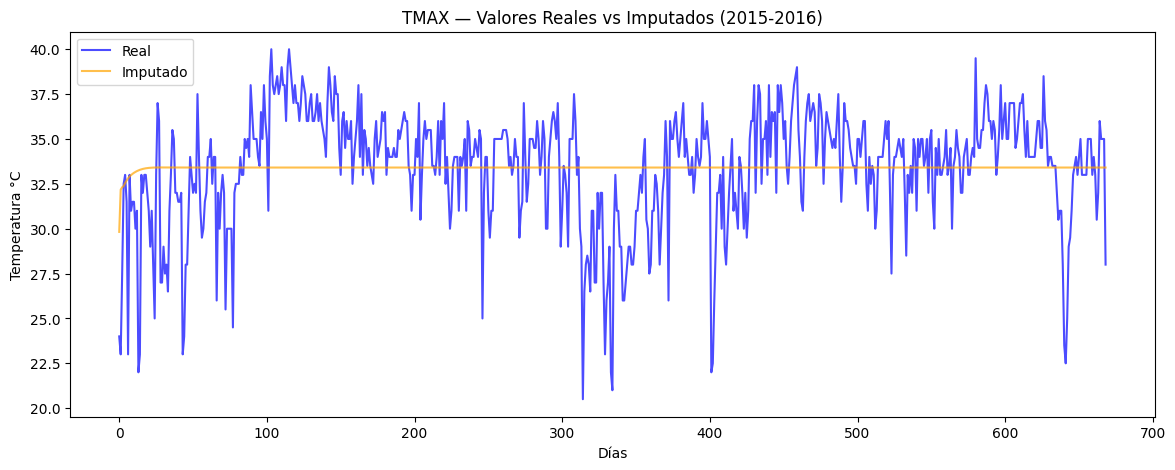

In [69]:
plt.figure(figsize=(14, 5))
plt.plot(tmax_real[:min_len], label="Real", color="blue", alpha=0.7)
plt.plot(predicciones_puntual[:min_len], label="Imputado", color="orange", alpha=0.7)
plt.title("TMAX — Valores Reales vs Imputados (2015-2016)")
plt.xlabel("Días")
plt.ylabel("Temperatura °C")
plt.legend()
plt.show()

In [ ]:
#El modelo muestra en la grafica que solo reconoce el patron general de la temperatura, pero no es capaz de predecir los picos de temperatura maxima, lo que se refleja en las metricas obtenidas.
# Para mejorar el modelo, podemos agregar más variables que puedan influir en la temperatura máxima, como el mes del año, ya que la temperatura suele tener patrones estacionales.
df_decada["mes"] = df_decada["FECHA"].dt.month

# Normalizar mes también
mes_values = df_decada["mes"].values.reshape(-1, 1)
mes_scaled = MinMaxScaler().fit_transform(mes_values)

tmax_mes_scaled = np.hstack([tmax_scaled, mes_scaled])

def crear_secuencias_2var(data, pasos=60):
    X, y = [], []
    for i in range(len(data) - pasos):
        X.append(data[i:i+pasos])
        y.append(data[i+pasos, 0])  # solo predecir TMAX
    return np.array(X), np.array(y)

X2, y2 = crear_secuencias_2var(tmax_mes_scaled)
print(X2.shape, y2.shape)

(2804, 60, 2) (2804,)


In [71]:
split = int(len(X2) * 0.7)

X2_train, X2_test = X2[:split], X2[split:]
y2_train, y2_test = y2[:split], y2[split:]

model3 = Sequential([
    LSTM(128, return_sequences=True, input_shape=(60, 2)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model3.compile(optimizer='adam', loss='mse', metrics=['mae'])

history3 = model3.fit(
    X2_train, y2_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

c:\ProyectoML\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0341 - mae: 0.1323 - val_loss: 0.0093 - val_mae: 0.0775
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 0.0165 - mae: 0.0975 - val_loss: 0.0111 - val_mae: 0.0873
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0157 - mae: 0.0970 - val_loss: 0.0086 - val_mae: 0.0733
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0161 - mae: 0.0973 - val_loss: 0.0094 - val_mae: 0.0777
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0147 - mae: 0.0926 - val_loss: 0.0093 - val_mae: 0.0768
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0142 - mae: 0.0916 - val_loss: 0.0149 - val_mae: 0.1042
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0148 - mae: 0.0937 - val_loss: 0.0139 - val_mae: 0.0988
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0153 - mae: 0.0958 - val_loss: 0.0090 - val_mae: 0.0751
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - l

In [ ]:
y2_pred = model3.predict(X2_test)

y2_test_real = scaler.inverse_transform(y2_test.reshape(-1, 1))
y2_pred_real = scaler.inverse_transform(y2_pred)

mse3 = mean_squared_error(y2_test_real, y2_pred_real)
mae3 = mean_absolute_error(y2_test_real, y2_pred_real)
r2_3 = r2_score(y2_test_real, y2_pred_real)

print(f"MSE: {mse3:.4f}")
print(f"MAE: {mae3:.4f}")
print(f"R²:  {r2_3:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
MSE: 4.2769
MAE: 1.5244
R²:  0.4981


In [73]:
predicciones_puntual3 = []

for idx in df_decada[mask_2años].index:
    pos = df_decada.index.get_loc(idx)
    if pos < 60:
        continue
    
    ventana_tmax = df_decada["TMAX"].iloc[pos-60:pos].values
    ventana_mes = df_decada["mes"].iloc[pos-60:pos].values
    
    ventana_tmax = pd.Series(ventana_tmax).fillna(df_decada["TMAX"].mean()).values
    
    ventana_tmax_scaled = scaler.transform(ventana_tmax.reshape(-1, 1))
    ventana_mes_scaled = MinMaxScaler().fit_transform(ventana_mes.reshape(-1, 1))
    
    ventana_input = np.hstack([ventana_tmax_scaled, ventana_mes_scaled]).reshape(1, 60, 2)
    
    pred_scaled = model3.predict(ventana_input, verbose=0)
    pred_real = scaler.inverse_transform(pred_scaled)[0, 0]
    predicciones_puntual3.append(pred_real)

predicciones_puntual3 = np.array(predicciones_puntual3)

# Métricas
min_len3 = min(len(tmax_real), len(predicciones_puntual3))
mse_f = mean_squared_error(tmax_real[:min_len3], predicciones_puntual3[:min_len3])
mae_f = mean_absolute_error(tmax_real[:min_len3], predicciones_puntual3[:min_len3])
r2_f = r2_score(tmax_real[:min_len3], predicciones_puntual3[:min_len3])

print(f"MSE: {mse_f:.4f}")
print(f"MAE: {mae_f:.4f}")
print(f"R²:  {r2_f:.4f}")

MSE: 10.6080
MAE: 2.5636
R²:  -0.0262


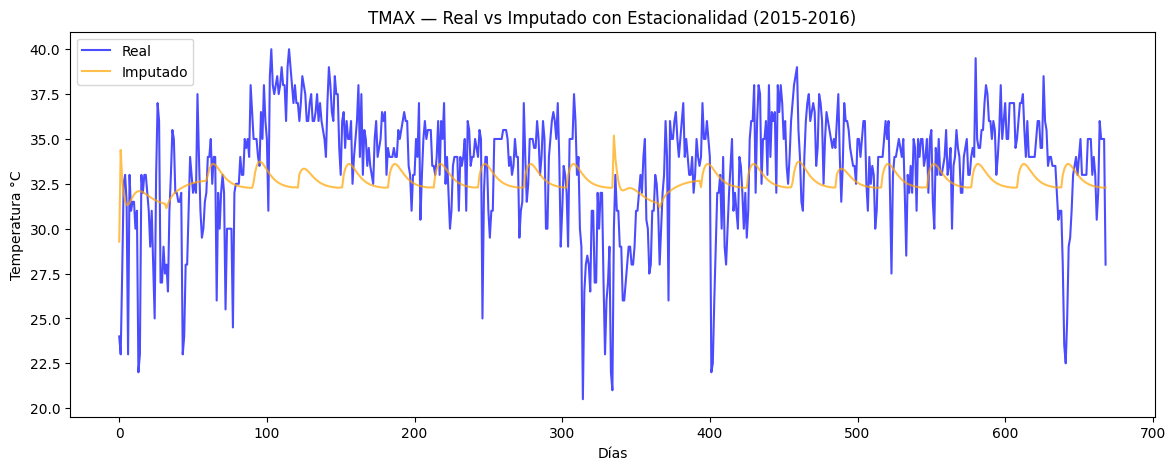

In [74]:
plt.figure(figsize=(14, 5))
plt.plot(tmax_real[:min_len3], label="Real", color="blue", alpha=0.7)
plt.plot(predicciones_puntual3[:min_len3], label="Imputado", color="orange", alpha=0.7)
plt.title("TMAX — Real vs Imputado con Estacionalidad (2015-2016)")
plt.xlabel("Días")
plt.ylabel("Temperatura °C")
plt.legend()
plt.show()

In [ ]:
#Con esto podemos concluir que el modelo mejoro significativamente al agregar la variable de mes, lo que indica que la estacionalidad es un factor importante para predecir la temperatura máxima.
#sin embargo, el modelo al ser de una decada con pocos datos, sigue sin ser perfecto, pero es un gran avance comparado con el modelo anterior.
